---
title: "Lecture 23: Power iteration"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture23_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

# Power iteration

As mentioned previously real-world data is often sparse, and matrix-vector multiplication is fast for sparse matrices, so this operation is quite efficient.  Methods based upon matrix-vector multiplications can be very efficient!  We'll see the most famous such algorithm in this lecture.

## Demo

In [4]:
# choose a random 5×5 matrix and a random 5-vector
A = rand(1.:9.,5,5)
A = A./sum(A,dims=1)
x = randn(5);

. . .

A couple of matrix multiplications doesn't reveal anything...

In [ ]:
y = A*x
z = A*y

5-element Vector{Float64}:
 -0.4648525306495378
 -0.3906696808395051
 -0.43771242969149005
 -0.48417551823260774
 -0.27727518393145867

. . .

But many matrix multiplications do!  Eventually $\mathbf{A}\mathbf{x} \approx \mathbf{x}$!

In [3]:
for j in 1:8;  x = A*x;  end
[x A*x]

5×2 Matrix{Float64}:
 -0.425632  -0.425623
 -0.406095  -0.406104
 -0.449525  -0.44954
 -0.438703  -0.438687
 -0.334731  -0.334732

---

This phenomenon seems to occur regardless of the starting vector.

In [5]:
x = randn(5)
for j in 1:8;  x = A*x;  end
[x A*x]

5×2 Matrix{Float64}:
 0.120363  0.120357
 0.105891  0.105897
 0.123079  0.123071
 0.133086  0.133085
 0.13006   0.13007

. . .

There was a little cheating in this demo to make the story come out neatly (specifically, the line `A=A./sum(A,dims=1)`). But it illustrates an important general fact that we investigate now.

## Dominant eigenvalue

Analysis of matrix powers is most straightforward in the diagonalizable case. Let $\mathbf{A}$ be any diagonalizable $n\times n$ matrix having eigenvalues $\lambda_1,\ldots,\lambda_n$ and corresponding linearly independent eigenvectors $\mathbf{v}_1,\ldots,\mathbf{v}_n$. 

. . .

Furthermore, suppose the eigenvalues are such that

$$|\lambda_1| > |\lambda_2| \ge |\lambda_3| \ge \cdots \ge |\lambda_n|.$$

. . .

Given such an ordering we say that $\lambda_1$ is the **dominant eigenvalue**. This was the case with $\lambda_1=1$ for $\mathbf{A}$ in the previous demo.

---

Now let $\mathbf{x}$ be an $n$-vector, let $k$ be a positive integer, and consider: 

$$\mathbf{A}^k \mathbf{x} = \mathbf{V}\mathbf{D}^k\mathbf{V}^{-1}\mathbf{x}.$$

. . .

Let $\mathbf{z}=\mathbf{V}^{-1}\mathbf{x}$, and recall that $\mathbf{D}$ is a diagonal matrix of eigenvalues. Then

$$\begin{split}
  \mathbf{A}^k\mathbf{x} &= \mathbf{V}\mathbf{D}^k \mathbf{z} = \mathbf{V}\begin{bmatrix} \lambda_1^kz_1 \\[0.5ex] \lambda_2^kz_2 \\ \vdots \\ \lambda_n^kz_n \end{bmatrix} \\
	&= \lambda_1^k \left[ z_1 \mathbf{v}_{1} +
		z_2 \left(\frac{\lambda_2}{\lambda_1}\right) ^k 
		\mathbf{v}_{2} + \cdots + z_n \left(\frac{\lambda_n}{\lambda_1}\right)^k
		\mathbf{v}_{n} \right].
\end{split}$$

. . .

Since $\lambda_1$ is dominant, we conclude that if $z_1\neq 0$,

$$\left\| \frac{ \mathbf{A}^k\mathbf{x}}{\lambda_1^k}
- z_1\mathbf{v}_1\right\| \le |z_2|\cdot\left|\frac{\lambda_2}{\lambda_1}\right| ^k
\| \mathbf{v}_{2} \| + \cdots +  |z_n|\cdot\left|\frac{\lambda_n}{\lambda_1}\right|^k
\| \mathbf{v}_{n} \| \rightarrow 0 \text{ as $k\rightarrow \infty$}.$$

[That is, $\mathbf{A}^k\mathbf{x}$ eventually is a scalar multiple of the dominant eigenvector as long as $z_i \not= 0$. If $\mathbf{x}$ is chosen randomly, the probability that $z_1=0$ is mathematically zero.]{.content-hidden when-format='revealjs' when-format='pptx'} 

[For algorithmic purposes, it is important to interpret $\mathbf{A}^k\mathbf{x}$ as $\mathbf{A}\bigl( \cdots\bigl( \mathbf{A} (\mathbf{A}\mathbf{x})\bigl) \cdots\bigl)$, i.e., as repeated applications of $\mathbf{A}$ to a vector. Doing so allows us to fully exploit sparsity of $\mathbf{A}$, something which is not preserved by taking a matrix power $\mathbf{A}^k$ explicitly before the multiplication with $\mathbf{x}$.]{.content-hidden when-format='revealjs' when-format='pptx'} 

## Power iteration

We don't quite yet have an algorithm.

. . .

Unless $|\lambda_1|=1$, the factor $\lambda_1^k$ tends to make $\|\mathbf{A}^k\mathbf{x}\|$ either very large or very small. Nor can we easily normalize by $\lambda_1^k$, unless we know $\lambda_1$ in advance.

. . .

To make a practical algorithm, we alternate matrix-vector multiplication with a renormalization of the vector. In the following, we use $x_{k,m}$ and $y_{k,m}$ to mean the $m$th component of vectors $\mathbf{x}_k$ and $\mathbf{y}_k$.

---

**Algorithm: Power iteration**

Given matrix $\mathbf{A}$:

1. Choose $\mathbf{x}_1$.
2. For $k=1,2,\ldots$, 
   
    a. Set $\mathbf{y}_k = \mathbf{A} \mathbf{x}_k$.
	
    b. Find $m$ such that $|y_{k,m}|=\|{\mathbf{y}_k} \|_\infty$.

    c. Set $\alpha_k = \dfrac{1}{y_{k,m}}$ and $\,\beta_k = \dfrac{y_{k,m}}{x_{k,m}}$.

    d. Set $\mathbf{x}_{k+1} = \alpha_k \mathbf{y}_k$.

<br><br>

. . .

Note that by definition, $\| \mathbf{x}_{k+1}\|_\infty=1$. Also, we can write

$$\mathbf{x}_{k} = (\alpha_1 \alpha_2 \cdots \alpha_k ) \mathbf{A}^k \mathbf{x}_{1}.$$

---

Finally, if $\mathbf{x}_k$ is nearly a dominant eigenvector of $\mathbf{A}$, then $\mathbf{A}\mathbf{x}_k$ is nearly $\lambda_1\mathbf{x}_k$, and we can take the ratio $\beta_k=y_{k,m}/x_{k,m}$ as an eigenvalue estimate. 

. . .

In fact, the extra $\alpha_j$ normalization factors cancel in the ratio, and, after some simplification, we get

$$\beta_k = \frac{y_{k,m}}{x_{k,m}} = \lambda_1
\frac{1+r_2^{k+1} b_2 + \cdots +  r_n^{k+1} b_n}{1+r_2^{k} b_2 +  \cdots +  r_n^{k} b_n},$$

where $r_j=\lambda_j/\lambda_1$ and the $b_j$ are constants. 

. . .

By the assumed ording of the eigenvalues, each $r_j$ satisfies $|r_j|<1$, so we see that $\beta_k\rightarrow \lambda_1$ as $k\rightarrow\infty$.

---

In [6]:
"""
    poweriter(A,numiter)

Perform `numiter` power iterations with the matrix `A`, starting
from a random vector. Returns a vector of eigenvalue estimates
and the final eigenvector approximation.
"""
function poweriter(A,numiter)
    n = size(A,1)
    x = normalize(randn(n),Inf)
    β = zeros(numiter)
    for k in 1:numiter
        y = A*x
        m = argmax(abs.(y))
        β[k] = y[m]/x[m]
        x = y/y[m]
    end
    return β,x
end

poweriter

. . .

Observe that the only use of $\mathbf{A}$ is to find the matrix-vector product $\mathbf{A}\mathbf{x}$, which easily exploits the sparsity of $\mathbf{A}$.

## Convergence

Let's examine the terms in the numerator and denominator of 

$$\beta_k = \frac{y_{k,m}}{x_{k,m}} = \lambda_1
\frac{1+r_2^{k+1} b_2 + \cdots +  r_n^{k+1} b_n}{1+r_2^{k} b_2 +  \cdots +  r_n^{k} b_n},$$

more carefully:

. . .

$$\begin{split}
r_2^{k} b_2 +  \cdots +  r_n^{k} b_n &= r_2^k \left[ b_2 + \left( \frac{r_3}{r_2} \right)^kb_3 + \cdots + \left( \frac{r_n}{r_2} \right)^kb_n \right] \\
&= r_2^k \left[ b_2 + \left( \frac{\lambda_3}{\lambda_2} \right)^kb_3 + \cdots + \left( \frac{\lambda_n}{\lambda_2} \right)^kb_n \right].
\end{split}$$

. . .

At this point we'll introduce an additional assumption,

$$|\lambda_2| > |\lambda_3| \ge \cdots \ge |\lambda_n|.$$

This isn't srictly necessary, but it makes the analysis easier.

---

With this assumption, we see 

$$r_2^{k} b_2 +  \cdots +  r_n^{k} b_n \rightarrow b_2 r_2^k \text{ as } k \rightarrow \infty.$$

. . .

Using a geometric series expansion for the denominator (and ignoring terms of order $2k$), we have

$$\begin{split}
\beta_k & \to \lambda_1 \left( 1+b_2 r_2^{k+1} \right) \left( 1 - b_2 r_2^{k} + O(r_2^{2k}) \right), \\
\beta_k - \lambda_1 &\to \lambda_1 b_2 (  r_2 - 1 ) r_2^{k}.
\end{split}$$

. . .

This is linear convergence with factor $r_2$:

$$\frac{\beta_{k+1} - \lambda_1}{\beta_{k}-\lambda_1} \rightarrow r_2 = \frac{\lambda_2}{\lambda_1} \quad \text{as } k\rightarrow \infty.$$

. . .

The error in the power iteration eigenvalue estimates $\beta_k$ is reduced asymptotically by a constant factor $\lambda_2/\lambda_1$ at each iteration.

---

We will experiment with the power iteration on a 5×5 matrix with prescribed eigenvalues and dominant eigenvalue at 1.

In [11]:
# | echo: false
using LinearAlgebra
using Plots

In [9]:
λ = [1,-0.75,0.6,-0.4,0]
# Make a triangular matrix with eigenvalues on the diagonal.
A = triu(ones(5,5),1) + diagm(λ)

5×5 Matrix{Float64}:
 1.0   1.0   1.0   1.0  1.0
 0.0  -0.75  1.0   1.0  1.0
 0.0   0.0   0.6   1.0  1.0
 0.0   0.0   0.0  -0.4  1.0
 0.0   0.0   0.0   0.0  0.0

In [10]:
β,x = poweriter(A,60)
eigval = β[end]

1.0000000020336843

---

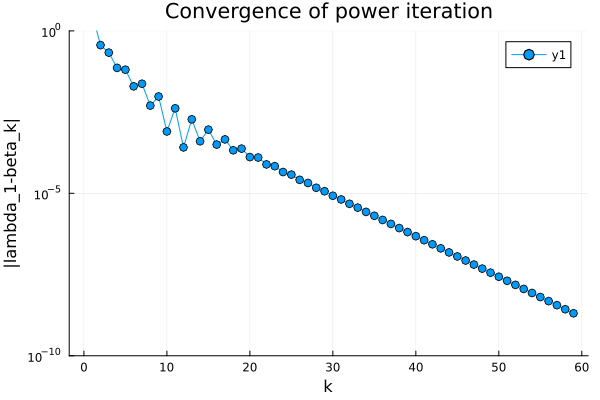

In [13]:
errs = @. 1 - β
plot(0:59,abs.(errs),m=:o,title="Convergence of power iteration",
    xlabel="k",yaxis=("|lambda_1-beta_k|",:log10,[1e-10,1]))

. . .

The asymptotic trend seems to be a straight line, consistent with linear convergence. To estimate the convergence rate, we look at the ratio of two consecutive errors in the linear part of the convergence curve. This should match the ratio of the first two eigenvalues.  

. . .

In [15]:
@show theory = λ[2]/λ[1];
@show observed = errs[40]/errs[39];

theory = λ[2] / λ[1] = -0.75
observed = errs[40] / errs[39] = -0.7533926119020397


---

Note that the error is supposed to change sign on each iteration. The effect of these alternating signs is that estimates oscillate around the exact value.

In [16]:
β[26:30]

5-element Vector{Float64}:
 1.0000376324242282
 0.9999739917615896
 1.0000208357312992
 0.9999851709375941
 1.0000116004151154

---

In practical situations, we don't know the exact eigenvalue that the algorithm is supposed to find. In that case we would base errors on the final $\beta$ that was found, as in the following plot.

. . .

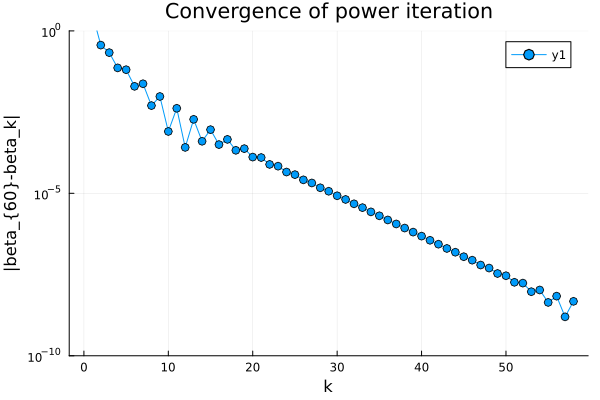

In [18]:
errs = @. β[end] - β[1:end-1]
plot(0:58,abs.(errs),m=:o,title="Convergence of power iteration",
    xlabel="k",yaxis=("|beta_{60}-beta_k|",:log10,[1e-10,1]))

. . .

The results are very similar until the last few iterations, when the limited accuracy of the reference value begins to show. That is, while it is a good estimate of $\lambda_1$, it is less good as an estimate of the error in nearby estimates.

---

The practical utility of our calculated convergence rate for the Power Iteration is limited because if we knew $\lambda_1$ and $\lambda_2$, we wouldn't be running the power iteration in the first place! 

. . .

Sometimes it's possible to find estimates of or bounds on the ratio. If nothing else, though, it is useful to know that linear convergence is expected at a rate based solely on the dominant eigenvalues. 

# Inverse iteration

Power iteration finds only the dominant eigenvalue. One can employ *deflation* techniques to alter the matrix $\mathbf{A}$ to find the next largest eigenvalue, but this is not always practical.

. . .

We next show that Power Iteration can be adapted to find any eigenvalue, provided you start with a reasonably good estimate of it. Some simple linear algebra is all that is needed.

## Inverse iteration

::: {.callout-warning icon=false}
## Theorem: 
Let $\mathbf{A}$ be an $n\times n$ matrix with eigenvalues $\lambda_1,\ldots,\lambda_n$ (possibly with repeats), and let $s$ be a complex scalar. Then:

1. The eigenvalues of the matrix $\mathbf{A}-s\mathbf{I}$ are $\lambda_1-s,\ldots,\lambda_n-s$.
2. If $s$ is not an eigenvalue of $\mathbf{A}$, the eigenvalues of the matrix $(\mathbf{A}-s\mathbf{I})^{-1}$ are $(\lambda_1-s)^{-1},\ldots,(\lambda_n-s)^{-1}$.
3. The eigenvectors associated with the eigenvalues in the first two parts are the same as those of $\mathbf{A}$.
:::

<details><summary>Proof:</summary> 

The equation $\mathbf{A}\mathbf{v}=\lambda \mathbf{v}$ implies that $(\mathbf{A}-s\mathbf{I})\mathbf{v} = \mathbf{A}\mathbf{v} - s\mathbf{I}\mathbf{v} = \lambda\mathbf{v} - s\mathbf{v} = (\lambda-s)\mathbf{v}$. That proves the first part of the theorem. 

For the second part, we note that by assumption, $(\mathbf{A}-s\mathbf{I})$ is nonsingular, so $(\mathbf{A}-s\mathbf{I})\mathbf{v} = (\lambda-s) \mathbf{v}$ implies that $\mathbf{v} = (\lambda-s)^{-1} (\mathbf{A}-s\mathbf{I}) \mathbf{v}$, or $(\lambda-s)^{-1} \mathbf{v} =(\mathbf{A}-s\mathbf{I})^{-1} \mathbf{v}$. 

The discussion above also proves the third part of the theorem.
</details>

. . .

Consider first part 2 of the theorem with $s=0$, and suppose that $\mathbf{A}$ has a *smallest* eigenvalue,

$$|\lambda_n| \ge |\lambda_{n-1}| \ge \cdots > |\lambda_1|.$$

. . .

Then $|\lambda_1^{-1}| > |\lambda_{2}^{-1}| \ge \cdots \ge |\lambda_n^{-1}|,$ and $\mathbf{A}^{-1}$ has a dominant eigenvalue. 

. . .

Hence power iteration on $\mathbf{A}^{-1}$ can be used to find the eigenvalue of $\mathbf{A}$ closest to zero. 

---

For nonzero values of $s$, then we suppose there is an ordering

$$|\lambda_n-s| \ge \cdots \ge |\lambda_2-s|  > |\lambda_1-s|.$$

. . .

Then it follows that

$$|\lambda_1-s|^{-1} > |\lambda_{2}-s|^{-1} \ge \cdots \ge |\lambda_n-s|^{-1},$$

and power iteration on the matrix $(\mathbf{A}-s\mathbf{I})^{-1}$ converges to $(\lambda_1-s)^{-1}$, which is easily solved for $\lambda_1$ itself.

## Algorithm

A literal application of the Power Iteration would include the step 

$$\mathbf{y}_k = (\mathbf{A}-s\mathbf{I})^{-1} \mathbf{x}_k.$$

. . .

As always, we do not want to explicitly find the inverse of a matrix. Instead we should write this step as the solution of a linear system.

---

**Algorithm: Inverse iteration**

Given matrix $\mathbf{A}$ and shift $s$:

1. Choose $\mathbf{x}_1$.

2. For $k=1,2,\ldots$, 

    a. Solve for $\mathbf{y}_k$ in
    $$(\mathbf{A}-s\mathbf{I}) \mathbf{y}_k =\mathbf{x}_k.$$

    b. Find $m$ such that $|y_{k,m}|=\|{\mathbf{y}_k} \|_\infty$.

    c. Set $\alpha_k = \dfrac{1}{y_{k,m}}$ and $\,\beta_k = s + \dfrac{x_{k,m}}{y_{k,m}}$.

    d. Set $\mathbf{x}_{k+1} = \alpha_k \mathbf{y}_k$.

. . .

In the Power Iteration, we used $y_{k,m}/x_{k,m}$ as an estimate of the dominant eigenvalue of $\mathbf{A}$. Here, that ratio is an estimate of $(\lambda_1-s)^{-1}$, and solving for $\lambda_1$ gives the $\beta_k$ in the Inverse Iteration.

---

Each pass of inverse iteration requires the solution of a linear system of equations with the matrix $\mathbf{B}=\mathbf{A}-s\mathbf{I}$. This solution might use methods we consider later in this chapter. Here, we use (sparse) PLU factorization and hope for the best. Since the matrix $\mathbf{B}$ is constant, the factorization needs to be done only once for all iterations. 

. . .


In [19]:
"""
    inviter(A,s,numiter)

Perform `numiter` inverse iterations with the matrix `A` and shift
`s`, starting from a random vector. Returns a vector of
eigenvalue estimates and the final eigenvector approximation.
"""
function inviter(A,s,numiter)
    n = size(A,1)
    x = normalize(randn(n),Inf)
    β = zeros(numiter)
    fact = lu(A - s*I)
    for k in 1:numiter
        y = fact\x
        normy,m = findmax(abs.(y))
        β[k] = x[m]/y[m] + s
        x = y/y[m]
    end
    return β,x
end

inviter

## Convergence

The convergence is linear, at a rate found by reinterpreting the Power Iteration convergence rate with $(\mathbf{A}-s\mathbf{I})^{-1}$ in place of $\mathbf{A}$:

$$\frac{\beta_{k+1} - \lambda_1}{\beta_{k} - \lambda_1} \rightarrow
\frac{  \lambda_1 - s } {\lambda_2 - s}\quad \text{ as } \quad k\rightarrow \infty,$$

with the eigenvalue order. Thus, the convergence is best when the shift $s$ is close to the target eigenvalue $\lambda_1$, specifically when it is much closer to that eigenvalue than to any other.

. . .

In [20]:
λ = [1,-0.75,0.6,-0.4,0]
# Make a triangular matrix with eigenvalues on the diagonal.
A = triu(ones(5,5),1) + diagm(λ)

5×5 Matrix{Float64}:
 1.0   1.0   1.0   1.0  1.0
 0.0  -0.75  1.0   1.0  1.0
 0.0   0.0   0.6   1.0  1.0
 0.0   0.0   0.0  -0.4  1.0
 0.0   0.0   0.0   0.0  0.0

---

As expected, Inverse Iteration finds the eigenvalue closest to 0.7.

In [21]:
s = 0.7
β,x = inviter(A,s,30)
eigval = β[end]

0.599999999999999

. . .

The convergence is again linear.

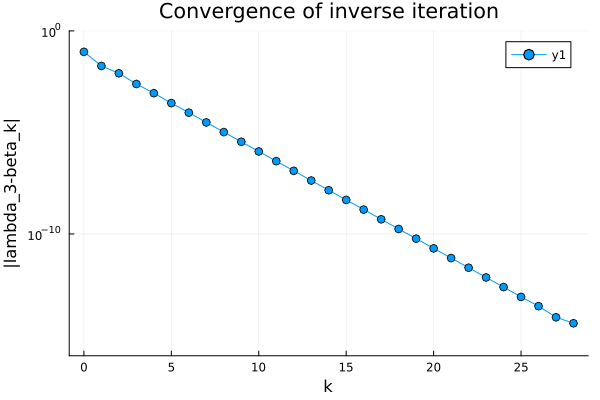

In [24]:
errs = @. abs(eigval-β)
plot(0:28,errs[1:end-1],m=:o,
    title="Convergence of inverse iteration",
    xlabel="k",yaxis=("|lambda_3-beta_k|",:log10,[1e-16,1]))

---

The observed linear convergence rate is found from the data.

In [26]:
@show observed_rate = errs[22]/errs[21];

observed_rate = errs[22] / errs[21] = 0.333263150706758


. . .

We reorder the eigenvalues to sort according to the shifted magnitude.

In [28]:
λ = λ[ sortperm(abs.(λ.-s)) ]

5-element Vector{Float64}:
  0.6
  1.0
  0.0
 -0.4
 -0.75

. . .

Hence the theoretical convergence rate is

In [29]:
@show theoretical_rate = (λ[1]-s) / (λ[2]-s);

theoretical_rate = (λ[1] - s) / (λ[2] - s) = -0.3333333333333332


## Dynamic shifting

There is a clear opportunity for positive feedback in the Inverse Iteration method. The convergence rate of inverse iteration improves as the shift gets closer to the true eigenvalue—and the algorithm computes improving eigenvalue estimates! If we update the shift to $s=\beta_k$ after each iteration, the convergence accelerates.

. . .

Let's analyze the resulting convergence. If the eigenvalues are ordered by distance to $s$, then the convergence is linear with rate $|\lambda_1-s|/|\lambda_2-s|$. As $s\to\lambda_1$, the change in the denominator is negligible. So if the error $(\lambda_1-s)$ is $\epsilon$, then the error in the next estimate is reduced by a factor $O(\epsilon)$. 

. . .

That is, $\epsilon$ becomes $O(\epsilon^2)$, which is *quadratic* convergence.

. . .

In [30]:
λ = [1,-0.75,0.6,-0.4,0]
# Make a triangular matrix with eigenvalues on the diagonal.
A = triu(ones(5,5),1) + diagm(λ) 

5×5 Matrix{Float64}:
 1.0   1.0   1.0   1.0  1.0
 0.0  -0.75  1.0   1.0  1.0
 0.0   0.0   0.6   1.0  1.0
 0.0   0.0   0.0  -0.4  1.0
 0.0   0.0   0.0   0.0  0.0

---

We begin with a shift $s=0.7$, which is closest to the eigenvalue 0.6.

In [ ]:
s = 0.7
x = ones(5)
y = (A-s*I)\x
β = x[1]/y[1] + s

for k in 1:4
    s = β  
    x = y/y[1]
    y = (A-s*I)\x  
    @show β = x[1]/y[1] + s
end                            # the number of accurate digits is doubling!

β = x[1] / y[1] + s = 0.5612761406172997
β = x[1] / y[1] + s = 0.5964312884753865
β = x[1] / y[1] + s = 0.5999717091820104
β = x[1] / y[1] + s = 0.5999999978556353


. . .

There is a price to pay for this improvement. The matrix of the linear system to be solved, $(\mathbf{A}-s\mathbf{I})$, now changes with each iteration. That means that we can no longer do just one LU factorization for the entire iteration. The speedup in convergence usually makes this tradeoff worthwhile, however.

. . .

In practice power and inverse iteration are not as effective as the algorithms used by `eigs` and based on the mathematics described in the next lectures. 

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise: 

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition: 
 
:::


::: {.callout-tip icon=false}
## Note: 
 
:::
-->